In [2]:
pip install pandas numpy nltk scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import nltk
import sklearn
import matplotlib
import seaborn

In [82]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to C:\Users\Acer
[nltk_data]     Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Acer
[nltk_data]     Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Acer
[nltk_data]     Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Acer
[nltk_data]     Nitro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from nltk.stem import WordNetLemmatizer


import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset and preprocessing

In [16]:
# Load dataset
df = pd.read_csv("data/Amazon_Unlocked_Mobile.csv")

# View basic info
df.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [18]:
df.shape

(413840, 6)

In [20]:
df.columns

Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes'],
      dtype='object')

In [24]:
df = df[['Brand Name', 'Rating', 'Reviews']]

df.head()

,Brand Name,Rating,Reviews
0,Samsung,5,I feel so LUCKY to have found this used (phone...
1,Samsung,4,"nice phone, nice up grade from my pantach revu..."
2,Samsung,5,Very pleased
3,Samsung,4,It works good but it goes slow sometimes but i...
4,Samsung,4,Great phone to replace my lost phone. The only...


In [26]:
df.columns = ['brand', 'rating', 'review_text']

df.head()

,brand,rating,review_text
0,Samsung,5,I feel so LUCKY to have found this used (phone...
1,Samsung,4,"nice phone, nice up grade from my pantach revu..."
2,Samsung,5,Very pleased
3,Samsung,4,It works good but it goes slow sometimes but i...
4,Samsung,4,Great phone to replace my lost phone. The only...


In [30]:
df.isnull().sum()

brand          65171
rating             0
review_text       70
dtype: int64

In [33]:
df = df.dropna()

df.isnull().sum()


brand          0
rating         0
review_text    0
dtype: int64

In [35]:
df = df[df['review_text'].str.strip() != '']

df.shape

(348616, 3)

In [37]:
selected_brands = ['Apple', 'Samsung', 'OnePlus', 'Xiaomi']

df = df[df['brand'].isin(selected_brands)]

df['brand'].value_counts()

brand
Samsung    65725
Apple      58179
OnePlus      438
Xiaomi        19
Name: count, dtype: int64

In [39]:
df = df.reset_index(drop=True)

df.head()

,brand,rating,review_text
0,Samsung,5,I feel so LUCKY to have found this used (phone...
1,Samsung,4,"nice phone, nice up grade from my pantach revu..."
2,Samsung,5,Very pleased
3,Samsung,4,It works good but it goes slow sometimes but i...
4,Samsung,4,Great phone to replace my lost phone. The only...


In [41]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

df.head()


,brand,rating,review_text,sentiment
0,Samsung,5,I feel so LUCKY to have found this used (phone...,positive
1,Samsung,4,"nice phone, nice up grade from my pantach revu...",positive
2,Samsung,5,Very pleased,positive
3,Samsung,4,It works good but it goes slow sometimes but i...,positive
4,Samsung,4,Great phone to replace my lost phone. The only...,positive


In [43]:
df['sentiment'].value_counts()


sentiment
positive    90539
negative    26472
neutral      7350
Name: count, dtype: int64

In [45]:
df[['rating', 'sentiment', 'review_text']].sample(5)


,rating,sentiment,review_text
113329,4,positive,I'm on the TMobile network and get LTE just fi...
66436,5,positive,GREAT PHONE FOR VALUE! Dual SIM capabilities e...
121753,1,negative,I purchased this phone from the seller and was...
42722,5,positive,The phone arrive in excellent condition--new a...
47896,5,positive,Perfect!!


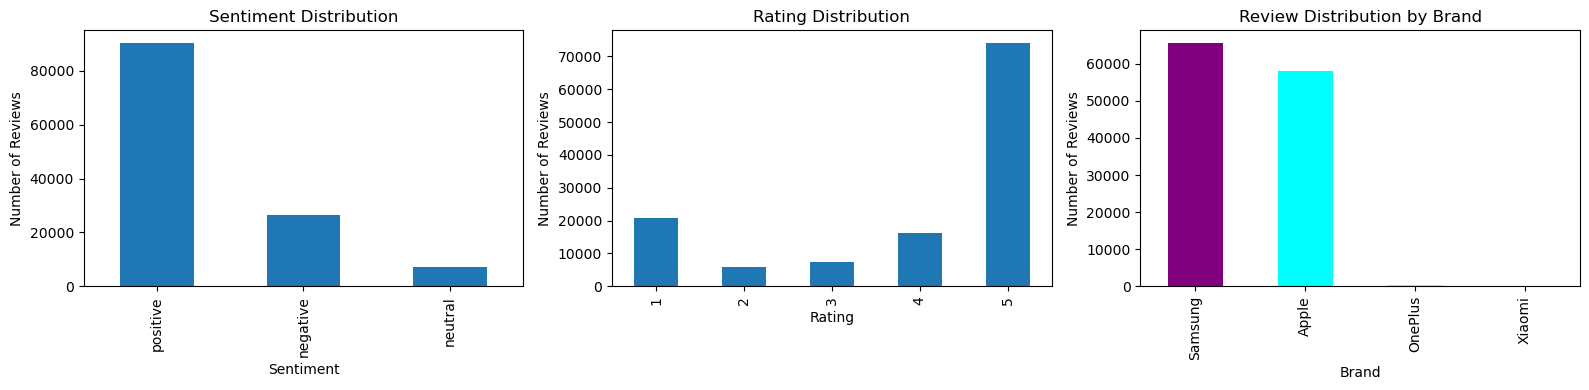

In [67]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Sentiment distribution
df['sentiment'].value_counts().plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')

# 2. Rating distribution
df['rating'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Number of Reviews')

# 3. Brand distribution with custom colors
brand_colors = ['purple', 'cyan', 'pink', 'orange']

df['brand'].value_counts().plot(
    kind='bar',
    ax=axes[2],
    color=brand_colors
)
axes[2].set_title('Review Distribution by Brand')
axes[2].set_xlabel('Brand')
axes[2].set_ylabel('Number of Reviews')

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=300)
plt.show()


# Text preprocessing

In [78]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [49]:
stop_words = set(stopwords.words('english'))


In [86]:
lemmatizer = WordNetLemmatizer()

In [91]:
  def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenize text into words
    tokens = word_tokenize(text)
    
    # Remove stopwords and apply lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    # Join tokens back to a single string
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text

In [93]:
df['clean_review'] = df['review_text'].apply(preprocess_text)

df.head()


,brand,rating,review_text,sentiment,clean_review
0,Samsung,5,I feel so LUCKY to have found this used (phone...,positive,feel lucky found used phone u used hard phone ...
1,Samsung,4,"nice phone, nice up grade from my pantach revu...",positive,nice phone nice grade pantach revue clean set ...
2,Samsung,5,Very pleased,positive,pleased
3,Samsung,4,It works good but it goes slow sometimes but i...,positive,work good go slow sometimes good phone love
4,Samsung,4,Great phone to replace my lost phone. The only...,positive,great phone replace lost phone thing volume bu...


In [95]:
df[['review_text', 'clean_review']].sample(3)


,review_text,clean_review
89448,Excelente,excelente
40801,The pone is not factor y unlocked and the Touc...,pone factor unlocked touch id dont work rest s...
122653,PURCHASE THIS FOR MY YOUNG SON AND HE TRULY EN...,purchase young son truly enjoy perfect use nee...


In [97]:
df[df['clean_review'].str.strip() == ''].shape

(0, 5)

In [99]:
df = df[df['clean_review'].str.strip() != '']
df = df.reset_index(drop=True)

# Feature engineering

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


In [104]:
X = df['clean_review']
y = df['sentiment']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [108]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [110]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [112]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(99132, 5000)
(24784, 5000)


In [114]:
tfidf.get_feature_names_out()[:20]

array(['ability', 'able', 'able activate', 'able connect', 'able get',
       'able return', 'able use', 'abroad', 'absolute', 'absolutely',
       'absolutely love', 'ac', 'accept', 'acceptable', 'accepted',
       'accesories', 'access', 'accessory', 'accessory included',
       'accident'], dtype=object)

# Model 1 Naive Bayes

In [117]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [119]:
nb_model = MultinomialNB()

In [121]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [123]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [125]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8755648805681084


In [127]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    negative       0.79      0.80      0.80      5289
     neutral       0.39      0.06      0.10      1469
    positive       0.90      0.96      0.93     18026

    accuracy                           0.88     24784
   macro avg       0.70      0.61      0.61     24784
weighted avg       0.85      0.88      0.85     24784



In [129]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_nb

array([[ 4256,    30,  1003],
       [  536,    84,   849],
       [  566,   100, 17360]], dtype=int64)

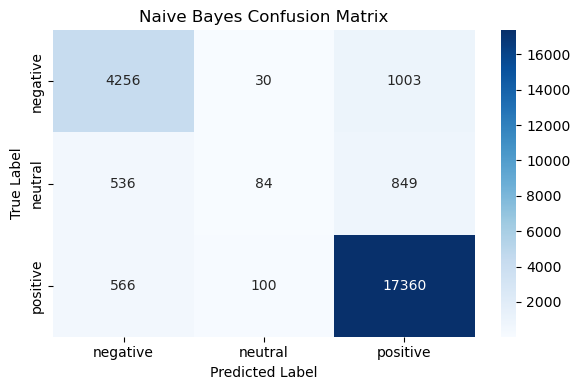

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Model 2 : Logistic Regression

In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [136]:
lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

In [138]:
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [140]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [142]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9024774047772757


In [144]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negative       0.84      0.87      0.85      5289
     neutral       0.59      0.19      0.28      1469
    positive       0.93      0.97      0.95     18026

    accuracy                           0.90     24784
   macro avg       0.79      0.68      0.70     24784
weighted avg       0.89      0.90      0.89     24784



In [146]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr

array([[ 4587,    85,   617],
       [  478,   275,   716],
       [  417,   104, 17505]], dtype=int64)

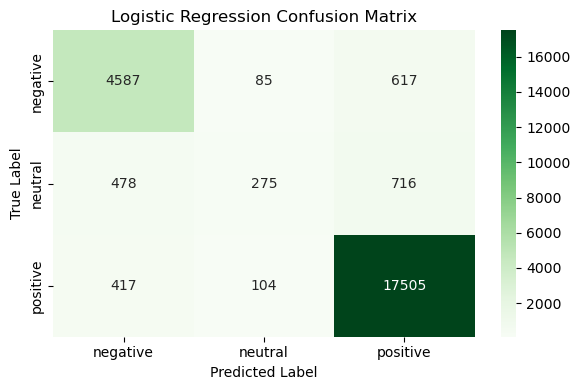

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [158]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_accuracy, lr_accuracy]
})

results

,Model,Accuracy
0,Naive Bayes,0.875565
1,Logistic Regression,0.902477


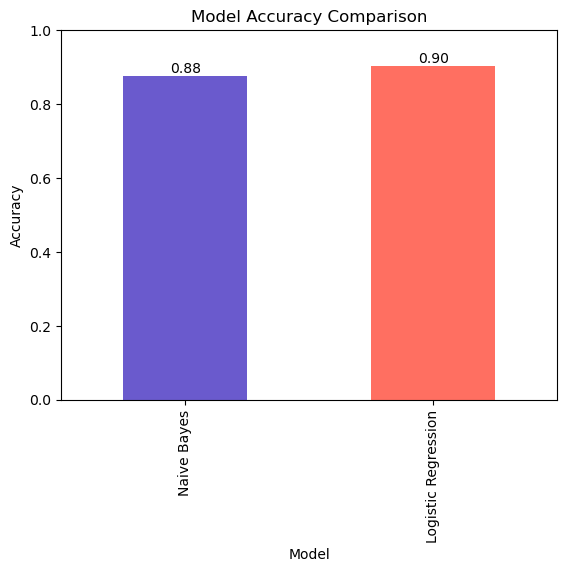

In [166]:
ax = results.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False,
    color=['#6a5acd', '#ff6f61']
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for i, v in enumerate(results['Accuracy']):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


In [168]:
# Transform full dataset using trained TF-IDF
X_all_tfidf = tfidf.transform(df['clean_review'])

# Predict sentiment using Logistic Regression
df['predicted_sentiment'] = lr_model.predict(X_all_tfidf)

df[['brand', 'predicted_sentiment']].head()


,brand,predicted_sentiment
0,Samsung,positive
1,Samsung,positive
2,Samsung,positive
3,Samsung,positive
4,Samsung,positive


In [170]:
brand_sentiment_counts = (
    df.groupby(['brand', 'predicted_sentiment'])
      .size()
      .reset_index(name='count')
)

brand_sentiment_counts


,brand,predicted_sentiment,count
0,Apple,negative,13393
1,Apple,neutral,1158
2,Apple,positive,43354
3,OnePlus,negative,71
4,OnePlus,neutral,4
5,OnePlus,positive,362
6,Samsung,negative,13855
7,Samsung,neutral,1165
8,Samsung,positive,50535
9,Xiaomi,negative,4


In [172]:
brand_sentiment_pivot = brand_sentiment_counts.pivot(
    index='brand',
    columns='predicted_sentiment',
    values='count'
).fillna(0)

brand_sentiment_pivot


predicted_sentiment,negative,neutral,positive
brand,,,
Apple,13393,1158,43354
OnePlus,71,4,362
Samsung,13855,1165,50535
Xiaomi,4,1,14


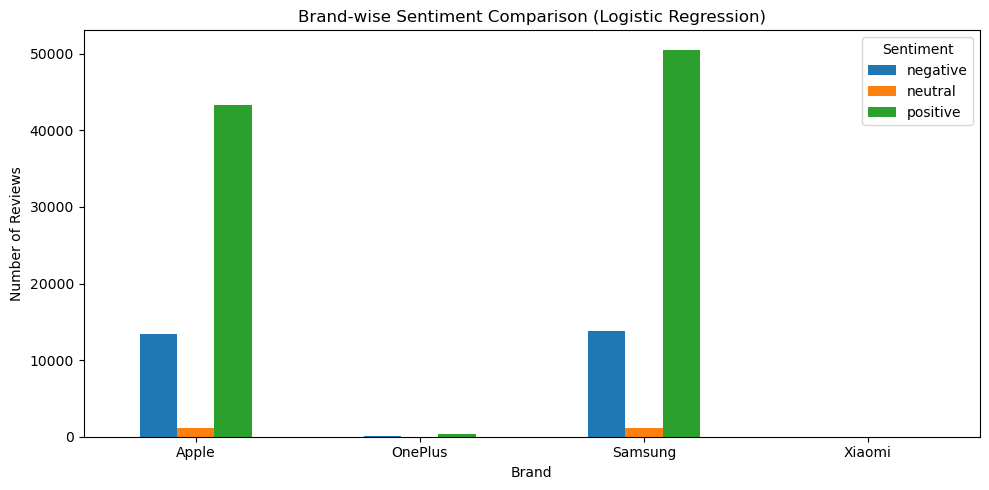

In [174]:
brand_sentiment_pivot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Brand-wise Sentiment Comparison (Logistic Regression)')
plt.xlabel('Brand')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


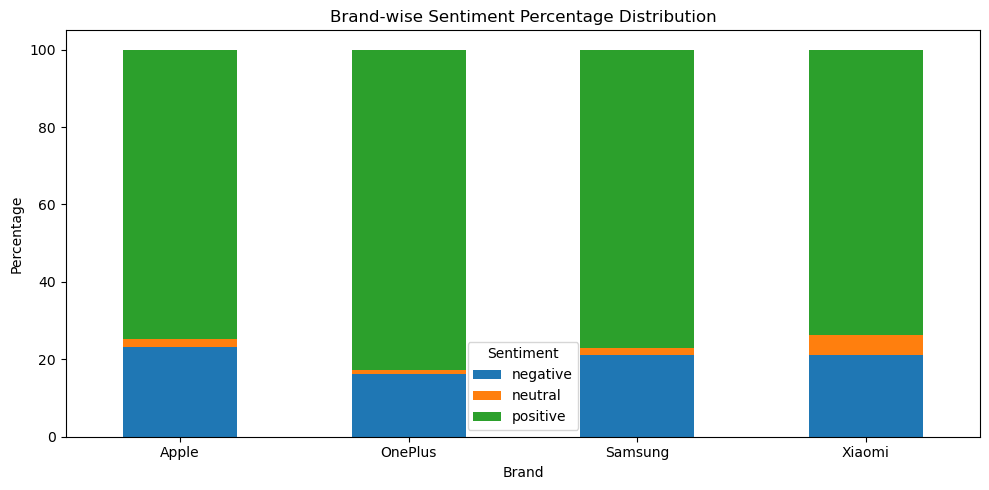

In [176]:
brand_sentiment_percent = brand_sentiment_pivot.div(
    brand_sentiment_pivot.sum(axis=1),
    axis=0
) * 100

brand_sentiment_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Brand-wise Sentiment Percentage Distribution')
plt.xlabel('Brand')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


In [178]:
df['brand'].value_counts()

brand
Samsung    65555
Apple      57905
OnePlus      437
Xiaomi        19
Name: count, dtype: int64